In [1]:
import matplotlib.pyplot as plt
import seaborn
# plt.style.use('seaborn')             ggplot;
import matplotlib as mpl
mpl.rcParams['font.family'] = 'serif'  



In [2]:
import numpy as np
import pandas as pd


In [3]:
import baostock as bs
lg = bs.login()

login success!


In [4]:
rs = bs.query_history_k_data_plus("sh.600000",
    "date,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST",
    start_date='2017-07-01', end_date='2017-12-31',
    frequency="d", adjustflag="3")

In [5]:
data_list = []
while (rs.error_code == '0') & rs.next():
    # 获取一条记录，将记录合并在一起
    data_list.append(rs.get_row_data())
data = pd.DataFrame(data_list, columns=rs.fields)


In [6]:
data.head()

,date,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST
0,2017-07-03,sh.600000,12.6400,12.6500,12.4700,12.5600,12.6500,38778949,486264672.0000,3,0.137985,1,-0.711456,0
1,2017-07-04,sh.600000,12.5500,12.5800,12.4100,12.5500,12.5600,36659128,458434432.0000,3,0.130442,1,-0.079620,0
2,2017-07-05,sh.600000,12.5000,12.6500,12.4700,12.6200,12.5500,26470507,332542464.0000,3,0.094188,1,0.557767,0
3,2017-07-06,sh.600000,12.6200,12.7200,12.5100,12.6600,12.6200,37414241,471582096.0000,3,0.133129,1,0.316957,0
4,2017-07-07,sh.600000,12.6200,12.6900,12.5500,12.6000,12.6600,24667294,311101536.0000,3,0.087772,1,-0.473929,0


In [7]:
len(data)

125

In [8]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=int(len(data)/3))

In [7]:
data['date'] = pd.to_datetime(data['date'])

In [8]:
data.set_index('date', inplace = True) 

In [9]:
data.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST
date,,,,,,,,,,,,,
2017-07-03,sh.600000,12.6400,12.6500,12.4700,12.5600,12.6500,38778949,486264672.0000,3,0.137985,1,-0.711456,0
2017-07-04,sh.600000,12.5500,12.5800,12.4100,12.5500,12.5600,36659128,458434432.0000,3,0.130442,1,-0.079620,0
2017-07-05,sh.600000,12.5000,12.6500,12.4700,12.6200,12.5500,26470507,332542464.0000,3,0.094188,1,0.557767,0
2017-07-06,sh.600000,12.6200,12.7200,12.5100,12.6600,12.6200,37414241,471582096.0000,3,0.133129,1,0.316957,0
2017-07-07,sh.600000,12.6200,12.6900,12.5500,12.6000,12.6600,24667294,311101536.0000,3,0.087772,1,-0.473929,0


In [12]:
n_splits = 2  # Number of splits
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=int(len(data) / 3))

In [13]:
for i, (train_index, test_index) in enumerate(tscv.split(data)):
    train = data.iloc[train_index]
    test = data.iloc[test_index]

In [10]:
data.rename(columns={'close': 'price'}, inplace=True) 

In [11]:
data['SMA_1'] = data['price'].rolling(1).mean() 
data['SMA_5'] = data['price'].rolling(5).mean() 
data['SMA_10'] = data['price'].rolling(10).mean()
data['SMA_15'] = data['price'].rolling(15).mean() 
data['SMA_20'] = data['price'].rolling(20).mean()

In [12]:
data.head(20)

,code,open,high,low,price,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST,SMA_1,SMA_5,SMA_10,SMA_15,SMA_20
date,,,,,,,,,,,,,,,,,,
2017-07-03,sh.600000,12.6400,12.6500,12.4700,12.5600,12.6500,38778949,486264672.0000,3,0.137985,1,-0.711456,0,12.56,NaN,NaN,NaN,NaN
2017-07-04,sh.600000,12.5500,12.5800,12.4100,12.5500,12.5600,36659128,458434432.0000,3,0.130442,1,-0.079620,0,12.55,NaN,NaN,NaN,NaN
2017-07-05,sh.600000,12.5000,12.6500,12.4700,12.6200,12.5500,26470507,332542464.0000,3,0.094188,1,0.557767,0,12.62,NaN,NaN,NaN,NaN
2017-07-06,sh.600000,12.6200,12.7200,12.5100,12.6600,12.6200,37414241,471582096.0000,3,0.133129,1,0.316957,0,12.66,NaN,NaN,NaN,NaN
2017-07-07,sh.600000,12.6200,12.6900,12.5500,12.6000,12.6600,24667294,311101536.0000,3,0.087772,1,-0.473929,0,12.60,12.598,NaN,NaN,NaN
2017-07-10,sh.600000,12.5900,12.6400,12.5200,12.5300,12.6000,26411530,331940512.0000,3,0.093979,1,-0.555561,0,12.53,12.592,NaN,NaN,NaN
2017-07-11,sh.600000,12.5100,12.9400,12.5100,12.8000,12.5300,96835349,1238626608.0000,3,0.344564,1,2.154832,0,12.80,12.642,NaN,NaN,NaN
2017-07-12,sh.600000,12.8000,13.0600,12.7400,12.8600,12.8000,80469025,1039614032.0000,3,0.286328,1,0.468746,0,12.86,12.690,NaN,NaN,NaN
2017-07-13,sh.600000,12.8200,13.2900,12.7700,13.2700,12.8600,110219238,1436784304.0000,3,0.392187,1,3.188187,0,13.27,12.812,NaN,NaN,NaN


In [13]:
data['price'] = list(map(float,data['price']))

<Axes: title={'center': ' SMAs'}, xlabel='date'>

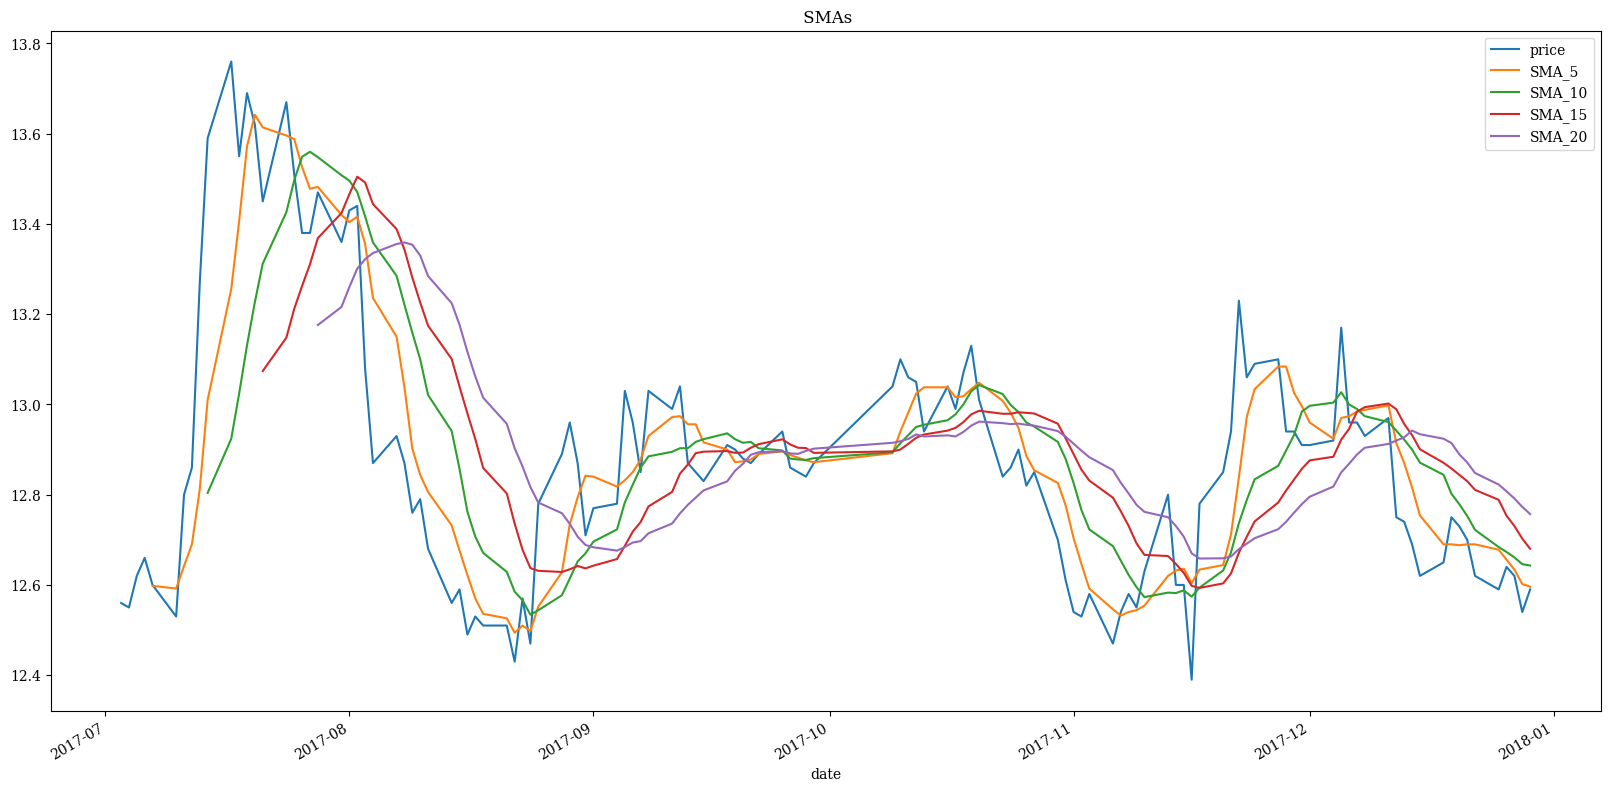

In [16]:
data[['price','SMA_5','SMA_10','SMA_15','SMA_20']].plot(title=' SMAs',
                                       figsize=(20, 10))

In [21]:
data['position'] = np.where(data['SMA_10'] > data['SMA_15'], 1, -1)

In [22]:
data.head()

,code,open,high,low,price,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST,SMA_1,SMA_5,SMA_10,SMA_15,SMA_20,position
date,,,,,,,,,,,,,,,,,,,
2017-07-03,sh.600000,12.6400,12.6500,12.4700,12.56,12.6500,38778949,486264672.0000,3,0.137985,1,-0.711456,0,12.56,NaN,NaN,NaN,NaN,-1
2017-07-04,sh.600000,12.5500,12.5800,12.4100,12.55,12.5600,36659128,458434432.0000,3,0.130442,1,-0.079620,0,12.55,NaN,NaN,NaN,NaN,-1
2017-07-05,sh.600000,12.5000,12.6500,12.4700,12.62,12.5500,26470507,332542464.0000,3,0.094188,1,0.557767,0,12.62,NaN,NaN,NaN,NaN,-1
2017-07-06,sh.600000,12.6200,12.7200,12.5100,12.66,12.6200,37414241,471582096.0000,3,0.133129,1,0.316957,0,12.66,NaN,NaN,NaN,NaN,-1
2017-07-07,sh.600000,12.6200,12.6900,12.5500,12.60,12.6600,24667294,311101536.0000,3,0.087772,1,-0.473929,0,12.60,12.598,NaN,NaN,NaN,-1


In [23]:
data.dropna(inplace=True)

<Axes: title={'center': 'Market Positioning'}, xlabel='date'>

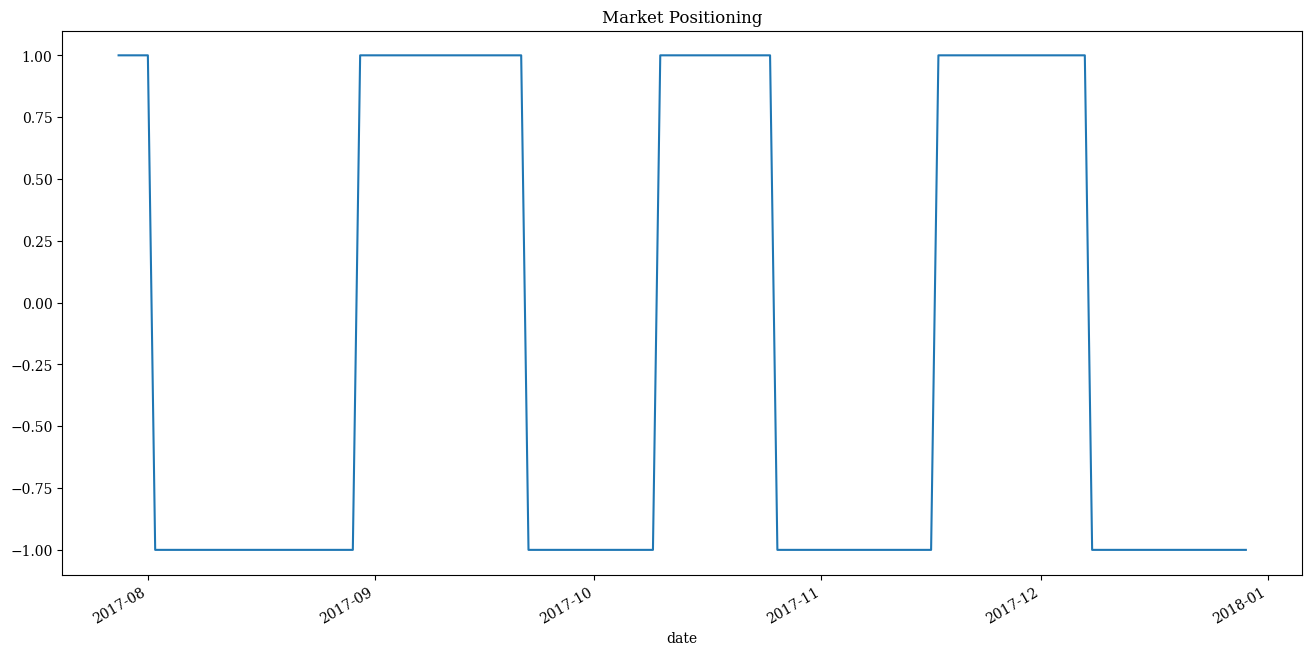

In [24]:
data['position'].plot(ylim=[-1.1, 1.1], figsize=(16,8),title='Market Positioning')

In [25]:
buy = data[data['position'] == 1]
sell = data[data['position'] == -1]

In [27]:
data['volume'] = list(map(float,data['volume']))

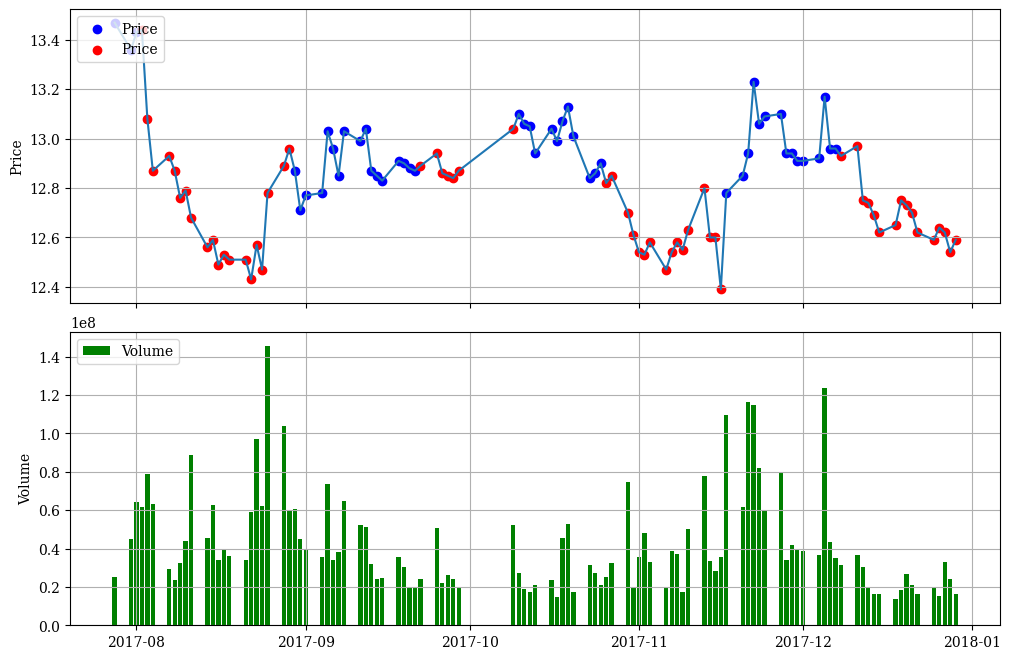

In [28]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))

# Plot price data as a scatter plot on ax1
ax1.plot(data['price'])
ax1.scatter(buy.index, buy['price'], color='blue', label='Price')
ax1.scatter(sell.index, sell['price'], color='r', label='Price')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')
ax1.grid(True)


ax2.bar(data.index, data['volume'], color='green', label='Volume', width=0.8)
ax2.set_ylabel('Volume')
ax2.legend(loc='upper left')
ax2.grid(True)

# Improve layout
plt.subplots_adjust(hspace=0.1)  # Adjust space between the two plots

In [29]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))    
#Numpy向量化；循环做法（尽量避免）,连续return

In [30]:
data.head()

,code,open,high,low,price,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST,SMA_1,SMA_5,SMA_10,SMA_15,SMA_20,position,returns
date,,,,,,,,,,,,,,,,,,,,
2017-07-28,sh.600000,13.3700,13.4900,13.3000,13.47,13.3800,24954961.0,334111568.0000,3,0.088796,1,0.672647,0,13.47,13.482,13.548,13.368667,13.176,1,NaN
2017-07-31,sh.600000,13.4500,13.5200,13.3100,13.36,13.4700,45083081.0,602638880.0000,3,0.160417,1,-0.816634,0,13.36,13.420,13.508,13.424000,13.216,1,-0.008200
2017-08-01,sh.600000,13.4200,13.4900,13.3200,13.43,13.3600,64198064.0,860914608.0000,3,0.228432,1,0.523957,0,13.43,13.404,13.496,13.466000,13.260,1,0.005226
2017-08-02,sh.600000,13.4400,13.6000,13.3900,13.44,13.4300,61644148.0,830433616.0000,3,0.219345,1,0.074455,0,13.44,13.416,13.471,13.504667,13.301,-1,0.000744
2017-08-03,sh.600000,13.4200,13.4200,13.0400,13.08,13.4400,78581867.0,1036842144.0000,3,0.279613,1,-2.678569,0,13.08,13.356,13.417,13.492000,13.322,-1,-0.027151


<Axes: >

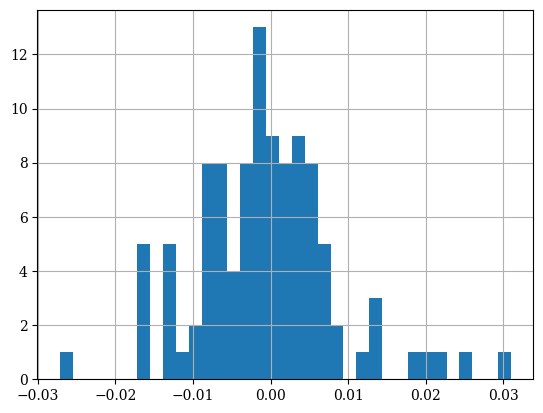

In [31]:
data['returns'].hist(bins=35)

In [32]:
data['strategy'] = data['position'].shift(1) * data['returns']     

In [33]:
data[['returns', 'strategy']].sum()

returns    -0.067562
strategy    0.046334
dtype: float64

<Axes: xlabel='date'>

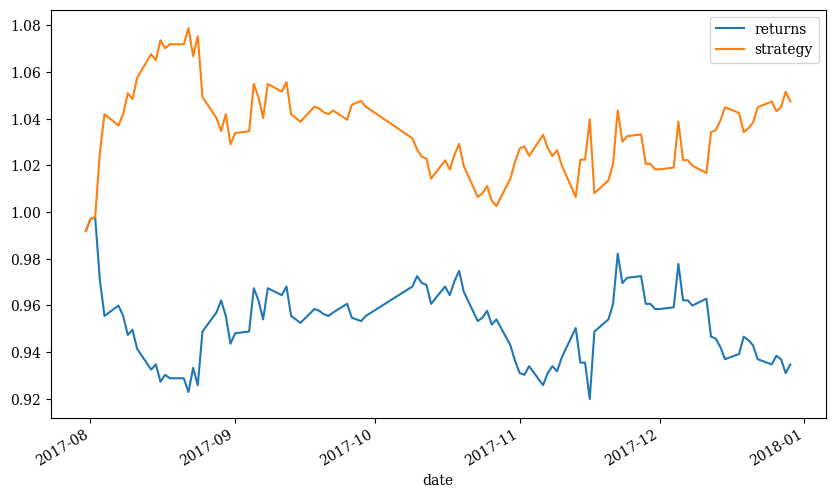

In [34]:
data[['returns', 'strategy']].cumsum().apply(np.exp).plot(figsize=(10, 6))   